## Package Imports

In [259]:
import warnings
import os
import numpy as np
import pandas as pd
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.colors as colors

warnings.filterwarnings('ignore')
os.environ['NUMPY_EXPERIMENTAL_ARRAY_FUNCTION'] = '0'

## Dask Cluster Setup
Uncomment and tune for your allocation. Key settings:
- `memory`: raise if kernel keeps crashing (workers get OOM-killed)
- `cores`/`processes`: 1 process per worker avoids GIL contention on numpy ops
- `walltime`: set generously — if workers die mid-compute everything restarts

In [260]:
from dask_jobqueue import PBSCluster
from dask.distributed import Client

cluster = PBSCluster(
    job_name        = 'hovmoller',
    cores           = 4,
    memory          = '64GiB',
    processes       = 1,
    resource_spec   = 'select=1:ncpus=4:mem=64GB',  # must match memory above
    queue           = 'casper',
    walltime        = '00:45:00',                    # 2 hours, not 30 min
    local_directory = '/glade/u/home/lilmi/scratch/dask_scratch/pbs.$PBS_JOBID/dask/spill',
    log_directory   = '/glade/u/home/lilmi/scratch/dask_scratch/pbs.$PBS_JOBID/dask/log',
    interface       = 'ext',
)
cluster.scale(6)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/lilmi/proxy/38645/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/lilmi/proxy/38645/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.102:39493,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/lilmi/proxy/38645/status,Total threads: 0
Started: Just now,Total memory: 0 B


## Configuration (Run Settings)

In [261]:
MODELS     = ['GFDL-CM4'] # the model(s) names to plot 
VARIABLES  = ['ph'] # the variable(s) to plot, for each model 
EXPERIMENT = 'piControl' # experiment name to plot (e.g. 'historical', 'ssp585', 'piControl')
FREQUENCY  = 'Omon' #frequency of the variable (Omon - ocean monthly) 
ACTIVITY   = 'CMIP' # activity to plot, "CMIP" for here, "ScenarioMIP" for future scenarios,
GRID_LIST  = ['gn', 'gr'] # grid list to choose, starting with native grid for here , use regridded if nec 

SO_LAT_RANGE  = (-90, -40)   # coarse Southern Ocean crop

# set one end to None for no lower or upper bound 
LEV_SLICE     = slice(None, 200) # set depth range to avrage over

## do you want to plot anomalies (True) or absolute values (False)?
ANOMALY = True         # subtract long-term mean?

## do you want to detrend (True - yes) or not (False - no)?
DETREND = True         # remove linear trend?

BANDS = {
    'southern': (-70, -58),
    'northern': (-58, -40),
}

## Helper Functions

In [262]:
################################### Data catalogue ###################################################

def get_path(model, variable, data_type, experiment_id, activity_id, grid_list):
    """Search GLADE CMIP6 catalogue and return file paths."""
    import intake
    # list of member ids to try, in order of preference (starting with r1i1p1f1) 
    member_id_list = ['r1i1p1f1', 'r1i1p1f2', 'r1i1p2f1', 'r4i1p1f1', 'r13i1p1f2']

    # open the GLADE CMIP6 catalogue using intake-esm
    cat = intake.open_esm_datastore(
        '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    )
    # search for the specified model, variable, experiment, activity, and member ids
    for run in member_id_list:
        sub = cat.search(experiment_id=[experiment_id], table_id=data_type,
                         variable_id=variable, source_id=model,
                         member_id=run, activity_id=activity_id)
        if sub.df.empty: # if no results, try next member id
            continue
            
        for grid in grid_list: # try each grid in order of preference (native or regridded)
            sub2 = cat.search(experiment_id=[experiment_id], table_id=data_type,
                              variable_id=variable, source_id=model,
                              member_id=run, activity_id=activity_id, grid_label=grid)
            if not sub2.df.empty:
                return sub2.df['path'].tolist() # sending path to list 

    # raise warning if no data found for any member id or grid option           
    warnings.warn(
        f'No data found for {model} {variable}',
        UserWarning
    )

    return None 

######################################## Chunking strategy ###################################################
def make_chunk_spec(paths, time_chunk=12, target_mb=300):
    """
    Chunk time and lev/y to hit target chunk size. x (longitude) is kept unchunked since it's the output dimension.
    """
    with xr.open_mfdataset(paths) as ds_meta: # open file to get metadata 
        dims = dict(ds_meta.sizes) # pulls dimensions from dataset and makes a dictionary of {dim_name: size}
    
    lat_dim = find_dim(ds_meta, ['y', 'lat', 'latitude', 'nlat']) # find the latitude dimension name using the find_dim function defined below
    lon_dim = find_dim(ds_meta, ['x', 'lon', 'longitude', 'nlon']) # find the longitude dimension name using the find_dim function defined below
    print("Latitude dimension:", lat_dim)
    print("Longitude dimension:", lon_dim)

    chunks = {} # initialize empty dictionary to hold chunk sizes for each dimension
    for dim, size in dims.items(): # loop through each dimension and its size in the dataset
        if dim == 'time': # chunk time into 12-month chunks (1 year) 
            chunks[dim] = time_chunk 
        elif dim == 'lev': # chunk vertical levels into ~4 chunks (adjust as needed based on typical number of levels and target chunk size)
            chunks[dim] = max(1, size // 4)   # aim for ~4 vertical chunks, but ensure at least 1 level per chunk
        elif dim == lat_dim:
            chunks[dim] = max(1, size // 4)   # aim for ~4 latitudinal chunks, but ensure at least 1 lat per chunk
        elif dim == lon_dim:
            chunks[dim] = -1                   # keep whole — it's the output dim
        else:
            chunks[dim] = -1                   # bnds, vertex etc

    return chunks
   

################## Identify dimensions in dataset ###################################################

def find_dim(ds, candidates):
    """Return first matching dimension name from candidates."""
    for c in candidates:
        if c in ds.dims:
            return c
    return None

def find_coord(da, candidates):
    '''Return first matching coordinate name from candidates, checking coords, variables, and attributes.'''
    for c in candidates:

        # DataArray case
        if hasattr(da, "coords") and c in da.coords:
            return c

        # Dataset case
        if hasattr(da, "variables") and c in da.variables:
            return c

        # also allow direct attributes (safe fallback)
        if hasattr(da, c):
            return c

    return None


##################Depth averaging ####################################################################

def compute_dz(ds, lev_bnds='lev_bnds'):
    ''' Compute layer thickness (dz) from vertical boundaries in the dataset.'''

    #lev_bnds = variable holding vertical boundaries (usually 2 values per level)
    # calculate the thickness (dz) of each depth cell
    #    'lev_bnds' has the shallower bound at index 0
    #    and the deeper bound at index 1.
    
    shallower_bnd = ds[lev_bnds].isel(bnds=0) # top depth of each vertical cell
    deeper_bnd    = ds[lev_bnds].isel(bnds=1) # bottom depth of each vertical cell
    dz = deeper_bnd - shallower_bnd # thickness of each vertical cell
    # no thickness = no contribution to weighted average, so set NaNs to zero
    dz = dz.fillna(0) # treat NaNs as zero thickness to avoid issues in weighted average

    return dz

def weighted_depth_avg(ds, var_name, lev_name=None, lev_slice=None):
    ''' computes a depth-weighted averge of the variable, accounting for layer thickness''' 

    if lev_name is None: # if lev_name not provided, try to find it
        lev_name = find_dim(ds, ['lev', 'depth', 'olevel', 'z'])

    if lev_name is None: # raise error if no vertical dimension found
        raise ValueError("No vertical dimension found")
    
    # get dz weights from compute_dz
    dz = compute_dz(ds) # get the layer thicknesses as weights for averaging (using function defined above)
       
    if lev_slice is not None:
        # https://docs.xarray.dev/en/stable/generated/xarray.DataArray.weighted.html
    
        ds = ds.sel(lev=lev_slice) # select only the levels within the specified slice for averaging
        dz = dz.sel(lev=lev_slice) # also select the corresponding dz values for those levels
    
    # calculate the weighted average:
    # apply the 'dz' array as weights and compute the mean along the 'lev' dimension
    #### takes ds to data array by pulling out the variable (ds[var_name]) and then 
    ### applies the weights and averages over the vertical dimension
    depth_avg = ds[var_name].weighted(dz).mean(dim=lev_name)
    
    # 'depth_avg' is your final DataArray with dimensions (time, space) after depth averaging
    return depth_avg

#################Spatial averaging ###################################################
# Average over y (latitude), keeping x (longitude) → (time, x) Hovmöller.
def zonal_mean_weighted(da, lat_range=None):
    """
    Latitude-weighted mean, preserving the longitude dimension.
    Works for both curvilinear (x/y dims) and regular (lat/lon dims) grids.
    """
    # ── detect lat coordinate and meridional/zonal dims ───────────────────
    lat_name = find_coord(da, ['lat', 'latitude', 'nav_lat', 'TLAT'])
    if lat_name is None:
        raise ValueError(f'No latitude coordinate found in {list(da.coords)}')

    # meridional dim = the dim we average over
    y_dim = find_dim(da, ['y', 'lat', 'latitude', 'nlat', 'j', 'nj'])
    # zonal dim = the dim we KEEP
    x_dim = find_dim(da, ['x', 'lon', 'longitude', 'nlon', 'i', 'ni'])

    if y_dim is None:
        raise ValueError(f'No meridional dimension found in {list(da.dims)}')
    if x_dim is None:
        raise ValueError(f'No zonal dimension found in {list(da.dims)}')

    lat = da[lat_name]

    # ── mask to lat band ───────────────────────────────────────────────────
    if lat_range is not None:
        lat_min, lat_max = lat_range
        da = da.where((lat >= lat_min) & (lat <= lat_max))
        lat = da[lat_name]

    # ── weights ────────────────────────────────────────────────────────────
    weights = np.cos(np.deg2rad(lat)).fillna(0)
    weights = weights.where(da.notnull(), 0)

    # ── average over y/lat ONLY, keep x/lon ───────────────────────────────
    return da.weighted(weights).mean(dim=y_dim)

########### Detrending ####################################################################
def linear_detrend(da, dim='time'):
    # 1. Fit a 1st degree polynomial (linear line) ignoring NaNs
    # This returns the coefficients (slope and intercept)
    p = da.polyfit(dim=dim, deg=1)
    
    # 2. Evaluate that line at all coordinates
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    
    # 3. Subtract the line from the original data
    return da - fit

#################Time averaging ###################################################
def annual_average(da):
    x_dim = find_dim(da, ['x', 'lon', 'longitude', 'nlon', 'i', 'ni'])
    x_coord = da[x_dim] if (x_dim and x_dim in da.coords) else None

    result = da.groupby('time.year').mean('time')

    # groupby drops non-index coords — restore lon if needed
    if x_coord is not None and x_dim not in result.coords:
        result = result.assign_coords({x_dim: x_coord})
    return result



## Load Data

In [263]:
raw_datasets = {} # create empty dictionary to hold datasets for each model and variable

for model in MODELS: # loop over models as specified above in MODELS list
    raw_datasets[model] = {} # create nested dictionary for each variable within each model key

    for var in VARIABLES: # loop over variables as specified above in VARIABLES list 
        print(f'Loading {model} - {var}') # print statement to track progress of loading datasets for each model and variable combination

        # get file paths from GLADE CMIP6 catalogue using the get_path function defined above
        paths = get_path(model, var, FREQUENCY, EXPERIMENT, ACTIVITY, GRID_LIST) # returns list of file paths 

        #create chunk specification for dask based on the dataset dimensions and target chunk size using the make_chunk_spec function defined above
        chunk_spec = make_chunk_spec(paths) 
        print(f'  chunks: {chunk_spec}')

        # open the dataset with xarray, applying the chunking specification for dask parallel processing
        ds = xr.open_mfdataset(
            paths,
            combine='by_coords',
            parallel=False,       
            chunks=chunk_spec
        )

        lat_dim = find_dim(ds, ['y', 'lat', 'latitude', 'nlat']) # get latitude dimension name using the find_dim function defined above
        lon_dim = find_dim(ds, ['x', 'lon', 'longitude', 'nlon']) # get longitude dimension name using the find_dim function defined above

        lat = ds['lat']

        if lat.ndim > 1: # if lat is 2D lat(x,y), average over the non-lat dimension to get a 1D lat array for masking
            reduce_dim = [d for d in lat.dims if d != lat_dim][0] # reduce over non-lat dimension (x) 
            lat_1d = lat.mean(reduce_dim) # gt one latitude value per latitude row 
        else:
            lat_1d = lat # if not 2D, just use as is for masking
            
        mask = (lat_1d >= SO_LAT_RANGE[0]) & (lat_1d <= SO_LAT_RANGE[1]) # mask to select only the latitudes within the specified Southern Ocean range

        ds = ds.isel({lat_1d.dims[0]: np.flatnonzero(mask.compute())})  # crop the data to  SO latitides 

        # rechunk y after crop since isel may create uneven chunks
        ds = ds.chunk({k: v for k, v in chunk_spec.items() if k in ds.dims})

        raw_datasets[model][var] = ds # store the opened and chunked dataset in the nested dictionary under the appropriate model and variable keys

Loading GFDL-CM4 - ph
Latitude dimension: lat
Longitude dimension: lon
  chunks: {'time': 12, 'lat': 45, 'bnds': -1, 'lon': -1, 'lev': 8}


In [265]:
#  check chunk size before running 
for model, var_dict in raw_datasets.items():
    for var, ds in var_dict.items():
        nbytes = ds[var].data.dtype.itemsize
        chunk_bytes = np.prod([c[0] for c in ds[var].chunks]) * nbytes
        print(f'{model} {var}: chunk size = {chunk_bytes / 1e9:.2f} GB')

GFDL-CM4 ph: chunk size = 0.01 GB


In [266]:
#test = raw_datasets['GFDL-CM4']['thetao']
#test

In [267]:
#lat_dim = find_dim(test , ['y', 'lat', 'latitude', 'nlat'])
#lon_dim = find_dim(test , ['x', 'lon', 'longitude', 'nlon'])
   
#print("Latitude dimension:", lat_dim)
#print("Longitude dimension:", lon_dim)

## Process Data: 
**Depth Avg -> Band Means -> Anomaly (Y/N)-> Annual (time) Means**

Everything stays lazy until the final `.compute()` at the end.
Dask will fuse all steps into one optimised graph per (model, var, band).

In [268]:
time_means = {} # create empty dictionary to hold time-averaged results for each model, variable, and band

for model, var_dict in raw_datasets.items(): # loop over each model and its corresponding variable dictionary in the raw_datasets nested dictionary
    time_means[model] = {} # create nested dictionary for each variable within each model key to hold time-averaged results 

    for var, ds in var_dict.items(): # loop over each variable and its corresponding dataset in the variable dictionary for each model
        print(f'Processing {model} - {var}') # print statement to track progress of processing each model and variable combination
        time_means[model][var] = {} # create another nested dictionary for each band within each variable key to hold time-averaged results for each band
        
        NO_DEPTH = False # flag to indicate whether depth averaging was performed (set to True if no vertical dimension found)
        if 'lev' not in ds.dims: # if no vertical dimension, skip this variable since we can't do depth averaging
            print('No depth dimension — skipping')
            depth_avg = ds[var] # if no vertical dimension, just use the variable as is without depth averaging
            NO_DEPTH = True

        # Step 1: depth average 
        if not NO_DEPTH: # if NO_DEPTH is False, meaning we have a vertical dimension and can do depth averaging, then compute the depth average using the weighted_depth_avg function defined above
            depth_avg = weighted_depth_avg(ds, var_name=var, lev_slice=LEV_SLICE)

        # Step 2 latutude averaging 
        byband_results = {} # create empty dictionary to hold results for each band, which will be computed together in one pass with dask.compute
        for band_name, lat_range in BANDS.items(): # loop over each band defined in BANDS dictionary, which contains the name and latitude range for each band to process
            
            zm = zonal_mean_weighted(depth_avg, lat_range=lat_range)  # (time, x)

            if ANOMALY: # if plotting anomalies, subtract the long-term mean from the zonal mean to get anomalies for each band
                # keep climatology in the same graph as zm
                # so dask only reads raw data once
                clim = zm.mean(dim='time')          # (x,) — part of same graph
                anom = zm - clim                    # (time, x)
            else: # if not plotting anomalies, just use the zonal mean as is for time averaging
                anom = zm
            
            if DETREND: # if detrending, remove the linear trend from the anomalies before time averaging
                anom = linear_detrend(anom, dim='time') # (time, x)

            #Step 3: average over time 
            ann = annual_average(anom)              # (year, x)
            byband_results[band_name] = ann

        # Step 4: one compute pass for all bands
        print(f'  Computing {list(BANDS.keys())}...')
        computed = dask.compute(*byband_results.values()) # compute all the results for each band together in one pass to optimize
        ## loop over each band and its corresponding computed result to store in the time_means nested dictionary under the appropriate model, variable, and band keys
        for band_name, result in zip(byband_results.keys(), computed): 
            time_means[model][var][band_name] = result

print('Done.')

Processing GFDL-CM4 - ph
  Computing ['southern', 'northern']...
Done.


In [272]:
time_means["GFDL-CM4"]["ph"]["southern"]

<xarray.DataArray (year: 500, lon: 360)> Size: 1MB
array([[-0.00748502, -0.00973548, -0.01144599, ..., -0.00309271,
        -0.00429952, -0.0052858 ],
       [-0.00322084, -0.00384608, -0.00670517, ..., -0.00290425,
        -0.00424887, -0.00480438],
       [-0.01152399, -0.01096305, -0.00777121, ..., -0.00983939,
        -0.01190565, -0.01301237],
       ...,
       [-0.00023318, -0.00285964, -0.00389475, ..., -0.00089169,
        -0.00016761,  0.00071422],
       [-0.00088181, -0.00156622, -0.00297845, ..., -0.00274617,
        -0.00247352, -0.00178825],
       [-0.00549579, -0.00458201, -0.00359873, ..., -0.00424242,
        -0.00675122, -0.00696491]], shape=(500, 360))
Coordinates:
  * year     (year) int64 4kB 151 152 153 154 155 156 ... 646 647 648 649 650
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    units:          1
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    interp_method:  conserve_order1
    original_name:  ph
    comment:        Model data on the 1x1 grid includes values in all cells f...
    axis:           T
    calendar_type:  noleap
    bounds:         time_bnds
    description:    Temporal mean

## Plotting

In [270]:
def plot_band(time_means, model, var, band, lev_description='', figsize=(6, 6),
              vmin=None, vmax=None, lon_start=-180, lon_min=None, lon_max=None,
              year_min=None, year_max=None, color_grid = 'bwr'):
    
    '''Plot Hovmöller diagram for a specific model, variable, and band.'''

    # make a copy of the DataArray for the specified model, variable, and band from the time_means nested dictionary 
    # to avoid modifying the original data when we do operations like rolling or masking for plotting
    da = time_means[model][var][band].copy()

    # ── detect lon dimension ─────────────────
    x_dim = find_dim(da, ['x', 'lon', 'longitude', 'nlon', 'i', 'ni'])
    if x_dim is None: # raise error if no longitude dim found for plotting
        raise ValueError(f'No longitude dimension found in {list(da.dims)}')

    # ── convert to 0-360, roll to lon_start ───────────────────────────────
    # takes lon given and converts to 0-360 for consistent handling, then rolls to the specified lon_start
    #### for ex if lon_start is -50 ; -50 mod(5) 360 is 310 
    lon_start_0360 = lon_start % 360 # convert lon_start to 0-360 for rolling
    x_0360 = da[x_dim].values % 360 # convert longitude coordinates to 0-360 for consistent handling, regardless of original format
    da = da.assign_coords({x_dim: x_0360}).sortby(x_dim) # replaces the longitude coordinates with the 0-360 version and sorts by longitude to ensure correct order for rolling and plotting
    x_rolled = (da[x_dim].values - lon_start_0360) % 360 + lon_start_0360 # roll the longitude coordinates so that the specified lon_start is at the left edge of the plot
    da = da.assign_coords({x_dim: x_rolled}).sortby(x_dim) # reassign shifted coords and sort again to ensure correct order after rolling

    # ── color normalisation ──────────────────────────────────────────────────────
    if vmin is None and vmax is None: # if no vmin/vmax provided, set symmetric limits around zero (for anomalies) or mean (for absolute)
        absmax = float(max(abs(da.min()), abs(da.max()))) # find absolute max and min values 
        vmin, vmax = -absmax, absmax # set vmin and vmax to be symmetric around zero for anomalies, or around the mean for absolute values
    vcenter = 0.0 if ANOMALY else float(da.mean()) # set vcenter to zero for anomalies, or to the mean value for absolute values, to ensure the colormap is centered appropriately
    if not (vmin < vcenter < vmax): #check v canter is in between vmin and vmax 
        vcenter = (vmin + vmax) / 2 # if not, just set to midpoint to avoid errors in TwoSlopeNorm

    norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    # ── plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize) # set figure params 
   
    # plot the data using xarray's built-in plotting, which handles the coordinates and dimensions appropriately 
    da.plot( x=x_dim, y='year', cmap= color_grid, norm=norm, ax=ax, cbar_kwargs={'label': f'{var} anomaly' if ANOMALY else var})


    def fmt_lon(val, _): # Function to format longitude labels in degrees with E/W and handle wrapping around 0/360
        v = ((val + 180) % 360) - 180 # convert to -180 to 180 range for labeling
        if v == 0:        return '0°' # label 0 
        if abs(v) == 180: return '180°' # label 180 (both E and W)
        return f'{abs(v):.0f}°{"E" if v > 0 else "W"}'

     # set the x-axis formatter to use the custom longitude formatting function defined above, 
     # which converts longitudes to a more readable format with E/W and handles wrapping around 0/360 correctly
    ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt_lon))

    if lon_min is not None or lon_max is not None: # if specific longitude limits are provided, set the x-axis limits accordingly, 
        lo = (lon_min % 360 - lon_start_0360) % 360 + lon_start_0360 if lon_min is not None else ax.get_xlim()[0]
        hi = (lon_max % 360 - lon_start_0360) % 360 + lon_start_0360 if lon_max is not None else ax.get_xlim()[1]
        ax.set_xlim(lo, hi)

    if year_min is not None or year_max is not None: # if specific year limits are provided, set the y-axis limits accordingly
        lo = year_min if year_min is not None else ax.get_ylim()[0]
        hi = year_max if year_max is not None else ax.get_ylim()[1]
        ax.set_ylim(lo, hi)

    # set the title of the plot to include the model, variable, band, and any description of the vertical levels used for averaging (e.g. depth range)
    ax.set_title(f'{model} | {var} | {band} | {lev_description}') 
    ax.set_xlabel('Longitude') # set x-axis label to "Longitude"
    ax.set_ylabel('Year') # set y-axis label to "Year"
    plt.tight_layout()
    plt.show()

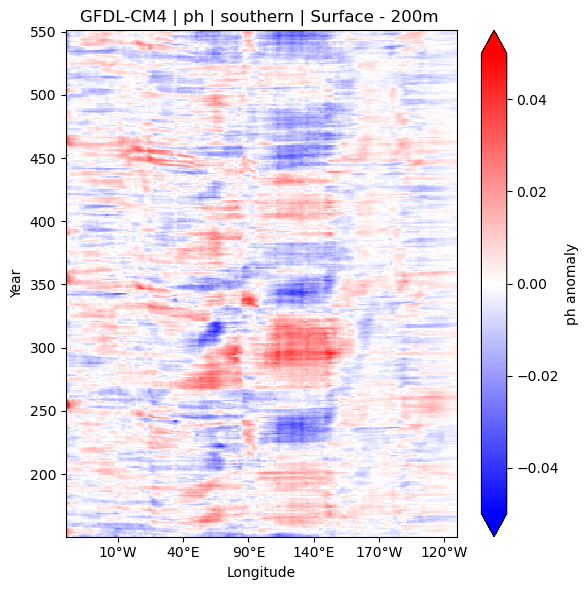

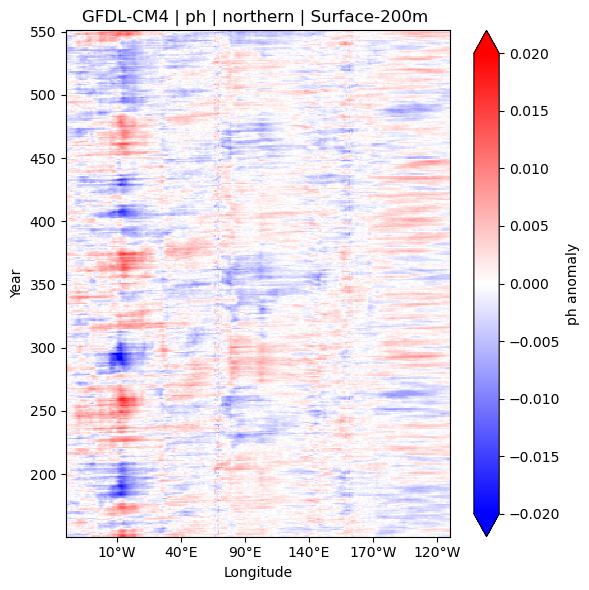

In [276]:
# Call the plotting function for each band, using the time-averaged results stored in the time_means nested dictionary for the specified model, variable, and band.
plot_band(time_means, 'GFDL-CM4', 'ph', 'southern', 'Surface - 200m ' ,vmin= -.05, vmax= .05, lon_start=-50,
          lon_min=None, lon_max=250, year_min=None, year_max= 151 + 400, color_grid = "bwr")
plot_band(time_means, 'GFDL-CM4', 'ph', 'northern', 'Surface-200m ',vmin= -.02, vmax= .02, lon_start=-50,
          lon_min=None, lon_max=250, year_min= None, year_max=151 + 400, color_grid = "bwr")